In [1]:
def sum_n_consecutive(data, n=100):
    # Assuming data is a numpy array
    n_rows = (len(data) // n) * n
    return data[:n_rows].reshape(-1, n).sum(axis=1)

In [2]:
def non_cumulative(fileList,normalization=1,title = ""):


    for  filename in fileList:
        try:
            data = np.genfromtxt(filename, delimiter=',', skip_header=1)
        except Exception as e:
            print("problem reading", filename, " : ",e)
            continue
    
        # Iterate over all columns except the first one (time)
        for col in range(1, 2):
            sum_times = sum_n_consecutive(data[:, 0],normalization)*1000/normalization # Assuming the first column is time
            sum_data = sum_n_consecutive(data[:, col],normalization)
    
            plt.plot(sum_times, sum_data,label=filename)
    
    plt.title(title)
    plt.xlabel('Time (millisecond)')
    plt.ylabel('Number of Molecules Received')
    plt.legend(loc='center left', bbox_to_anchor=(0.62, 0.8))  # to place the legend outside of the plot
    plt.grid(True)
    #plt.savefig(output+output_file_name+" sum = "+str(normalization_parameter))
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # to place the legend outside of the plot
    plt.show()

In [3]:
def cumulative(fileList,title = ""):

    for filename in fileList:
        try:
            data = np.genfromtxt(filename, delimiter=',', skip_header=1)
        except Exception as e:
            print("problem reading", filename, " : ", e)
            continue

        # Iterate over all columns except the first one (time)
        for col in range(1, 2):
            times = data[:, 0] * 1000   # Assuming the first column is time
            cum_data = np.cumsum(data[:, col])

            plt.plot(times, cum_data, label=filename)

    plt.title(title)
    plt.xlabel('Time (millisecond)')
    plt.ylabel('Cumulative Number of Molecules Received')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # to place the legend outside of the plot
    plt.grid(True)
    plt.show()

In [10]:
def h_bar_plot(fileList,title=""):   
    # Replace this list with your actual file names
    for filename in fileList:
        interval_width = 2000  # interval width in milliseconds

        
        barList = []
        try:
            reader = np.genfromtxt(filename, delimiter=',', skip_header=1)
        except Exception as e:
            print("problem reading", filename, ":", e)
            pass
        
        # Convert reader to a numpy array if it isn't already
        data = np.array(reader, dtype=float)
        
        # Replace empty or NaN entries with 0
        data[np.isnan(data)] = 0
        
        # Convert time to milliseconds in the first column
        data[:, 0] = data[:, 0] * 1000
        
        # Calculate cumulative sum for the second column
        cum_data = np.cumsum(data[:, 1])
        
        # Calculating the number of bars and height of each bar
        barList = [cum_data[interval_width*(i+1)] - cum_data[interval_width*i] for i in range((20000-interval_width)//interval_width)]
        print(barList)
        # Plotting
        plt.figure(figsize=(10, 6))
        plt.bar(range(0,20000-interval_width,interval_width), barList, width=interval_width//1.5, align='edge', edgecolor='black')
        plt.title(title)
        plt.xlabel('Time (milliseconds)')
        plt.ylabel('Cumulative Number of Molecules Received')
        plt.grid(True)
        plt.show()


In [11]:
def plotter(fileList,normalization):
    non_cumulative(fileList,normalization,"noncumulative")
    cumulative(fileList,"cumulative")
    h_bar_plot(fileList,"h bar plot")

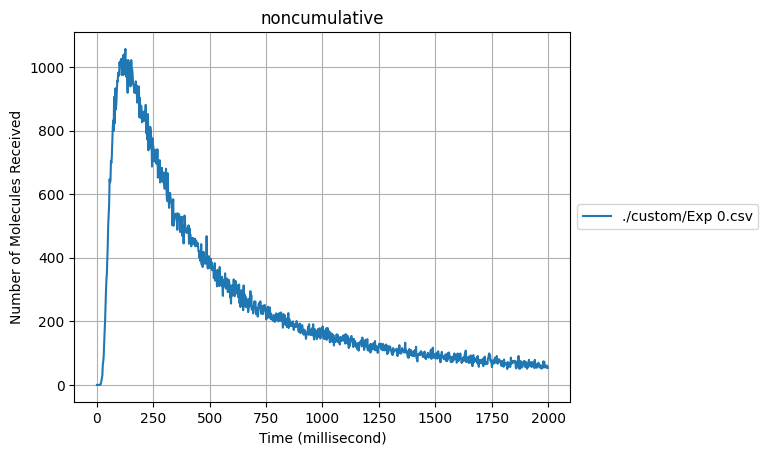

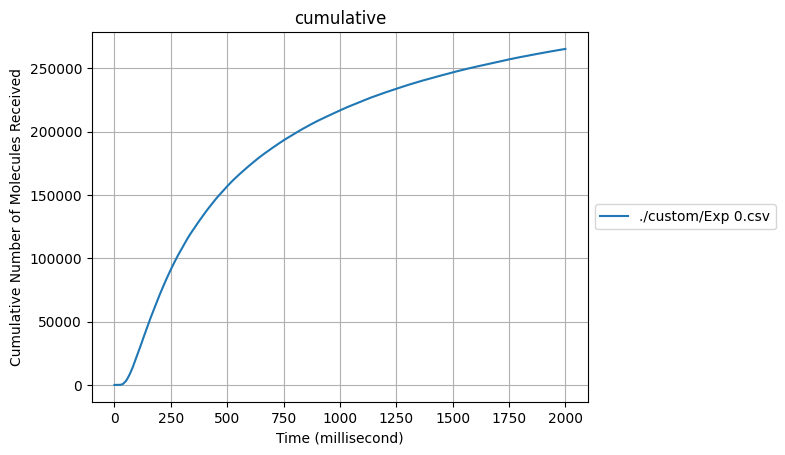

[70918.0, 64459.0, 38022.0, 25042.0, 18228.0, 14135.0, 11106.0, 9128.0, 7734.0]


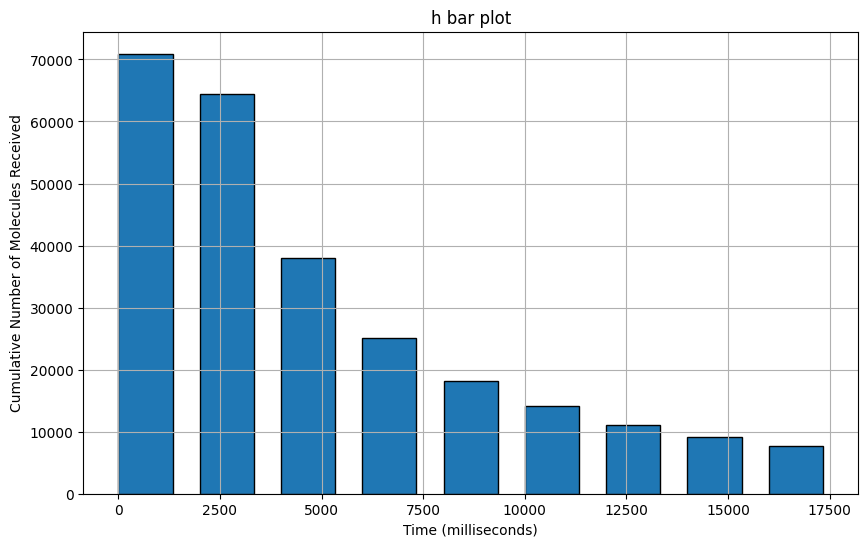

In [12]:
import numpy as np
import matplotlib.pyplot as plt
plotter(["./custom/Exp 0.csv"],20)


In [8]:
def sum_n_consecutive(data, n=50):
    # Assuming data is a numpy array
    n_rows = (len(data) // n) * n
    return data[:n_rows].reshape(-1, n).sum(axis=1)